Libraries

In [42]:
import pandas as pd
from matplotlib import pyplot as plt
import datetime as dt

Loading the main dataset of stop times & info

In [29]:
transitdf = pd.read_csv('static_data/stop_times.txt')
transitdf.head()

,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint
0,14827490,5:10:00,5:10:00,646,1,NaN,0,0,NaN,1
1,14827490,5:17:53,5:17:53,1277,10,NaN,0,0,3.4113,0
2,14827490,5:18:49,5:18:49,1279,11,NaN,0,0,3.8104,0
3,14827490,5:20:07,5:20:07,56,12,NaN,0,0,4.3660,0
4,14827490,5:20:41,5:20:41,12619,13,NaN,0,0,4.6101,0


In [30]:
transitdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 1833817 entries, 0 to 1833816
Data columns (total 10 columns):
 #   Column               Dtype  
---  ------               -----  
 0   trip_id              int64  
 1   arrival_time         str    
 2   departure_time       str    
 3   stop_id              int64  
 4   stop_sequence        int64  
 5   stop_headsign        float64
 6   pickup_type          int64  
 7   drop_off_type        int64  
 8   shape_dist_traveled  float64
 9   timepoint            int64  
dtypes: float64(2), int64(6), str(2)
memory usage: 139.9 MB


In [31]:
transitdf = transitdf[['trip_id', 'arrival_time', 'stop_id']]
transitdf.head()

,trip_id,arrival_time,stop_id
0,14827490,5:10:00,646
1,14827490,5:17:53,1277
2,14827490,5:18:49,1279
3,14827490,5:20:07,56
4,14827490,5:20:41,12619


Filtering for route name and stop code using trips & stops dataset

In [32]:
tripsdf = pd.read_csv('static_data/trips.txt')
tripnamesdf = tripsdf[['trip_id', 'trip_headsign']]
tripnamesdf.head()


,trip_id,trip_headsign
0,14827490,2 Macdonald/To Burrard Station
1,14827491,2 Macdonald/To Burrard Station
2,14827492,2 Macdonald/To Burrard Station
3,14827493,2 Macdonald/To Burrard Station
4,14827494,2 Macdonald/To Burrard Station


In [33]:
stopsdf = pd.read_csv("static_data/stops.txt")
stopsdf = stopsdf[['stop_id', 'stop_code']]
stopsdf['stop_id'] = pd.to_numeric(stopsdf['stop_id'], downcast='integer', errors='coerce')
stopsdf.head()

,stop_id,stop_code
0,1.0,50001.0
1,10000.0,59326.0
2,10001.0,59324.0
3,10002.0,59323.0
4,10003.0,59325.0


Joining tables to filter for 99-B line

In [34]:
transitdf = pd.merge(transitdf, tripnamesdf, on=['trip_id'])
transitdf = pd.merge(transitdf, stopsdf, on=['stop_id'])
transitdf.head(10)

,trip_id,arrival_time,stop_id,trip_headsign,stop_code
0,14827490,5:10:00,646,2 Macdonald/To Burrard Station,50640.0
1,14827490,5:17:53,1277,2 Macdonald/To Burrard Station,51267.0
2,14827490,5:18:49,1279,2 Macdonald/To Burrard Station,51269.0
3,14827490,5:20:07,56,2 Macdonald/To Burrard Station,50056.0
4,14827490,5:20:41,12619,2 Macdonald/To Burrard Station,60359.0
5,14827490,5:21:03,58,2 Macdonald/To Burrard Station,50058.0
6,14827490,5:21:29,59,2 Macdonald/To Burrard Station,50059.0
7,14827490,5:22:09,61,2 Macdonald/To Burrard Station,50061.0
8,14827490,5:22:49,63,2 Macdonald/To Burrard Station,50063.0
9,14827490,5:23:16,64,2 Macdonald/To Burrard Station,50064.0


In [35]:
trip_name = "99 Broadway B-Line/To UBC Exchange"
blinedf = transitdf[(transitdf['trip_headsign'] == trip_name)]
blinedf.head()

,trip_id,arrival_time,stop_id,trip_headsign,stop_code
1568370,14898231,5:38:00,2110,99 Broadway B-Line/To UBC Exchange,52092.0
1568371,14898231,5:54:17,12822,99 Broadway B-Line/To UBC Exchange,60579.0
1568372,14898231,5:57:00,11088,99 Broadway B-Line/To UBC Exchange,58501.0
1568373,14898231,5:57:59,934,99 Broadway B-Line/To UBC Exchange,50926.0
1568374,14898231,6:00:40,545,99 Broadway B-Line/To UBC Exchange,50540.0


Obtaining first & last stops and elapsed times

In [36]:
# start_stopcode = 58491
# end_stopcode = 61935

start_stopcode = 50913
end_stopcode = 60358

bline_start_end_df = blinedf[(blinedf['stop_code'] == start_stopcode) | (blinedf['stop_code'] == end_stopcode)]
bline_start_end_df

,trip_id,arrival_time,stop_id,trip_headsign,stop_code
1568380,14898231,6:18:00,12600,99 Broadway B-Line/To UBC Exchange,60358.0
1568385,14898231,5:45:00,11606,99 Broadway B-Line/To UBC Exchange,50913.0
1568416,14898233,6:32:00,12600,99 Broadway B-Line/To UBC Exchange,60358.0
1568421,14898233,5:59:00,11606,99 Broadway B-Line/To UBC Exchange,50913.0
1568435,14898234,6:44:00,12600,99 Broadway B-Line/To UBC Exchange,60358.0
...,...,...,...,...,...
1579444,14900143,24:52:00,11606,99 Broadway B-Line/To UBC Exchange,50913.0
1579458,14900144,25:53:00,12600,99 Broadway B-Line/To UBC Exchange,60358.0
1579459,14900144,25:22:00,11606,99 Broadway B-Line/To UBC Exchange,50913.0
1579473,14900145,26:23:00,12600,99 Broadway B-Line/To UBC Exchange,60358.0


In [37]:
bline_start_end_df['arrival_time'] = pd.to_datetime(bline_start_end_df['arrival_time'], format= '%H:%M:%S', errors = 'coerce')
bline_start_end_df['ending_time'] = bline_start_end_df.groupby('trip_id')['arrival_time'].shift(1)
bline_start_end_df['delta_time'] = (bline_start_end_df['ending_time'] - bline_start_end_df['arrival_time'])
bline_start_end_df = bline_start_end_df[pd.notnull(bline_start_end_df['delta_time'])]
bline_start_end_df.head()

,trip_id,arrival_time,stop_id,trip_headsign,stop_code,ending_time,delta_time
1568385,14898231,1900-01-01 05:45:00,11606,99 Broadway B-Line/To UBC Exchange,50913.0,1900-01-01 06:18:00,0 days 00:33:00
1568421,14898233,1900-01-01 05:59:00,11606,99 Broadway B-Line/To UBC Exchange,50913.0,1900-01-01 06:32:00,0 days 00:33:00
1568440,14898234,1900-01-01 06:08:00,11606,99 Broadway B-Line/To UBC Exchange,50913.0,1900-01-01 06:44:00,0 days 00:36:00
1568459,14898235,1900-01-01 06:13:00,11606,99 Broadway B-Line/To UBC Exchange,50913.0,1900-01-01 06:49:00,0 days 00:36:00
1568478,14898236,1900-01-01 06:18:00,11606,99 Broadway B-Line/To UBC Exchange,50913.0,1900-01-01 06:54:00,0 days 00:36:00


New dataframe with cleaned values

In [48]:
max_time = dt.datetime(1900, 1, 1, hour = 13)

bline_to_ubc = bline_start_end_df.reset_index()
bline_to_ubc = bline_to_ubc[['arrival_time', 'ending_time', 'delta_time']]
bline_to_ubc = bline_to_ubc[(bline_to_ubc['ending_time'] <= max_time)]
bline_to_ubc['delta_time_min'] = bline_to_ubc['delta_time'].dt.total_seconds().div(60)
bline_to_ubc

,arrival_time,ending_time,delta_time,delta_time_min
0,1900-01-01 05:45:00,1900-01-01 06:18:00,0 days 00:33:00,33.0
1,1900-01-01 05:59:00,1900-01-01 06:32:00,0 days 00:33:00,33.0
2,1900-01-01 06:08:00,1900-01-01 06:44:00,0 days 00:36:00,36.0
3,1900-01-01 06:13:00,1900-01-01 06:49:00,0 days 00:36:00,36.0
4,1900-01-01 06:18:00,1900-01-01 06:54:00,0 days 00:36:00,36.0
...,...,...,...,...
375,1900-01-01 11:41:00,1900-01-01 12:25:00,0 days 00:44:00,44.0
376,1900-01-01 11:49:00,1900-01-01 12:33:00,0 days 00:44:00,44.0
377,1900-01-01 11:57:00,1900-01-01 12:41:00,0 days 00:44:00,44.0
378,1900-01-01 12:06:00,1900-01-01 12:50:00,0 days 00:44:00,44.0


{'whiskers': [<matplotlib.lines.Line2D at 0x1f17dd002f0>,
 'caps': [<matplotlib.lines.Line2D at 0x1f17dd00590>,
 'boxes': [<matplotlib.lines.Line2D at 0x1f17dd001a0>],
 'medians': [<matplotlib.lines.Line2D at 0x1f17dd00830>],
 'fliers': [<matplotlib.lines.Line2D at 0x1f17dd00980>],
 'means': []}

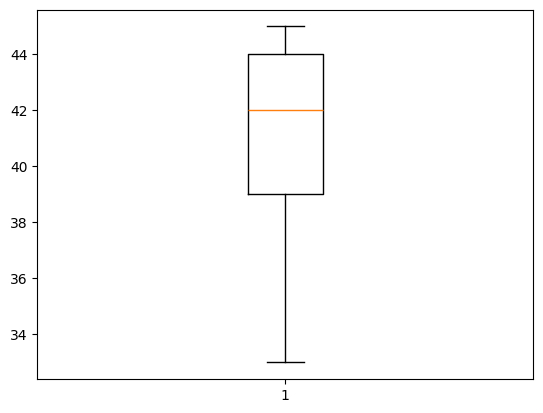

In [49]:
plt.boxplot(bline_to_ubc['delta_time_min'])